In [1]:
import pandas as pd

In [2]:
desi = pd.read_excel('C:\\Users\\semanur\\Desktop\\HB_Yarisma\\data\\Desi_talep.xlsx')

In [3]:
desi.head()

,Çıkış Transfer Merkezi,Varış Transfer Merkezi,Tarih,Toplam Desi
0,Mersin,Eskişehir,2026-01-01,379.50
1,Kocaeli,Şanlıurfa,2026-01-01,1239.48
2,Kocaeli,Tekirdağ,2026-01-01,2852.70
3,Sivas,Eskişehir,2026-01-01,638.60
4,Kocaeli,Sivas,2026-01-01,1001.60


In [4]:
desi.info

<bound method DataFrame.info of       Çıkış Transfer Merkezi Varış Transfer Merkezi      Tarih  Toplam Desi
0                     Mersin              Eskişehir 2026-01-01       379.50
1                    Kocaeli              Şanlıurfa 2026-01-01      1239.48
2                    Kocaeli               Tekirdağ 2026-01-01      2852.70
3                      Sivas              Eskişehir 2026-01-01       638.60
4                    Kocaeli                  Sivas 2026-01-01      1001.60
...                      ...                    ...        ...          ...
10765                Kocaeli              Eskişehir 2026-05-10       145.60
10766                 Manisa               Tekirdağ 2026-05-10        72.60
10767                Kocaeli              Şanlıurfa 2026-05-10       388.12
10768                Kocaeli                 Mersin 2026-05-10      4280.40
10769                 Manisa                 Yalova 2026-05-10       455.04

[10770 rows x 4 columns]>

In [6]:
desi.isnull().sum()

Çıkış Transfer Merkezi    0
Varış Transfer Merkezi    0
Tarih                     0
Toplam Desi               0
dtype: int64

In [7]:
desi.dtypes

Çıkış Transfer Merkezi            object
Varış Transfer Merkezi            object
Tarih                     datetime64[ns]
Toplam Desi                      float64
dtype: object

In [7]:
print("\n" + "=" * 50)
print("3. TARİH ARALIĞI")
print("=" * 50)
print(f"İlk tarih  : {desi['Tarih'].min()}")
print(f"Son tarih  : {desi['Tarih'].max()}")
print(f"Toplam gün : {desi['Tarih'].nunique()}")


3. TARİH ARALIĞI
İlk tarih  : 2026-01-01 00:00:00
Son tarih  : 2026-05-10 00:00:00
Toplam gün : 130


In [8]:
print("\n" + "=" * 50)
print("4. DESİ İSTATİSTİKLERİ")
print("=" * 50)
print(desi['Toplam Desi'].describe())


4. DESİ İSTATİSTİKLERİ
count    10770.000000
mean     11603.350648
std       9768.833758
min          5.180000
25%       4669.500000
50%       9449.300000
75%      16153.740000
max      67808.200000
Name: Toplam Desi, dtype: float64


In [9]:
print("\n" + "=" * 50)
print("5. EN YOĞUN 10 ROTA")
print("=" * 50)
top_routes = desi.groupby(['Çıkış Transfer Merkezi','Varış Transfer Merkezi'])['Toplam Desi'].mean().sort_values(ascending=False).head(10)
print(top_routes)


5. EN YOĞUN 10 ROTA
Çıkış Transfer Merkezi  Varış Transfer Merkezi
İstanbul                Yalova                    30234.121386
                        Eskişehir                 29171.073810
Kocaeli                 Yalova                    28889.913592
İstanbul                Manisa                    26609.853333
                        Balıkesir                 26427.595313
                        Tekirdağ                  23883.482791
Kocaeli                 İstanbul                  23214.554769
                        Tekirdağ                  23148.110769
Yalova                  Eskişehir                 22568.405510
Kocaeli                 Balıkesir                 22092.253538
Name: Toplam Desi, dtype: float64


In [10]:
print("\n" + "=" * 50)
print("6. HAFTALIK PATTERN")
print("=" * 50)
desi['Haftanin_Gunu'] = desi['Tarih'].dt.day_name()
gunluk = desi.groupby('Haftanin_Gunu')['Toplam Desi'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
print(gunluk)


6. HAFTALIK PATTERN
Haftanin_Gunu
Monday       19223.376047
Tuesday      14476.035458
Wednesday    13517.556796
Thursday     11731.004000
Friday       11280.244521
Saturday      8142.017585
Sunday        2892.499072
Name: Toplam Desi, dtype: float64


In [11]:
desi['Rota'] = (
    desi['Çıkış Transfer Merkezi'].astype(str)
    + ' -> ' +
    desi['Varış Transfer Merkezi'].astype(str)
)

print("Toplam rota sayısı:", desi['Rota'].nunique())

Toplam rota sayısı: 89


In [15]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 3.7 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/9.3 MB 3.3 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.3 MB 2.9 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.3 MB 2.8 MB/s eta 0:00:03
   ---------- ----------------------------- 2.4/9.3 MB 2.8 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.3 MB 2.2 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.3 MB 2.2 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.3 MB 2.2 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.3 MB 1.7 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.3 MB 1.7 MB/s eta 0:00:04
   --------------- -------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker



desi['Haftanin_Gunu'] = desi['Tarih'].dt.dayofweek
desi['gun_adi'] = desi['Tarih'].dt.day_name()


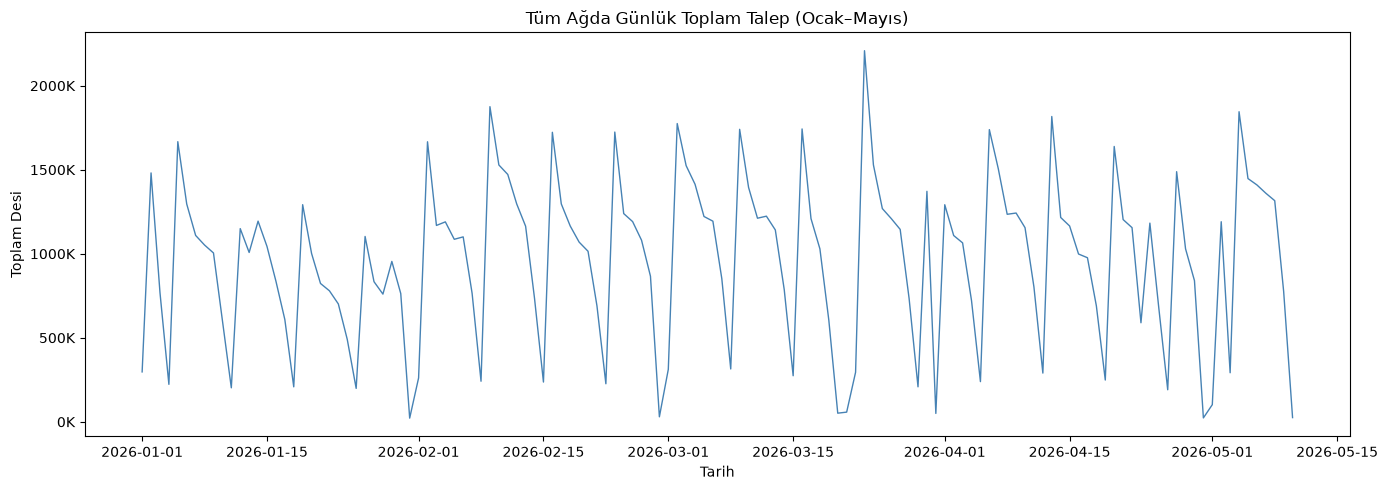

In [50]:
# --- PLOT 1: Günlük toplam talep (zaman serisi) ---

gunluk_toplam = desi.groupby('Tarih')['Toplam Desi'].sum()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(gunluk_toplam.index, gunluk_toplam.values, color='steelblue', linewidth=1)

ax.set_title("Tüm Ağda Günlük Toplam Talep (Ocak–Mayıs)")
ax.set_ylabel("Toplam Desi")
ax.set_xlabel("Tarih")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

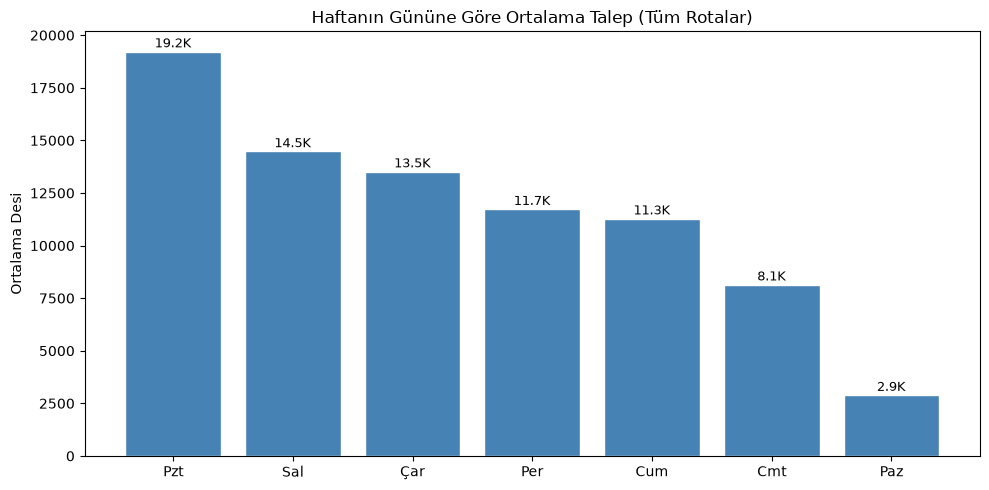

In [52]:
# --- PLOT 2: Haftalık ortalama (tüm ağ) ---


gun_sira = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
gun_tr = ['Pzt','Sal','Çar','Per','Cum','Cmt','Paz']

haftalik = desi.groupby('gun_adi')['Toplam Desi'].mean().reindex(gun_sira)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(gun_tr, haftalik.values, color='steelblue', edgecolor='white')

ax.set_title("Haftanın Gününe Göre Ortalama Talep (Tüm Rotalar)")
ax.set_ylabel("Ortalama Desi")

for bar, val in zip(bars, haftalik.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{val/1000:.1f}K',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

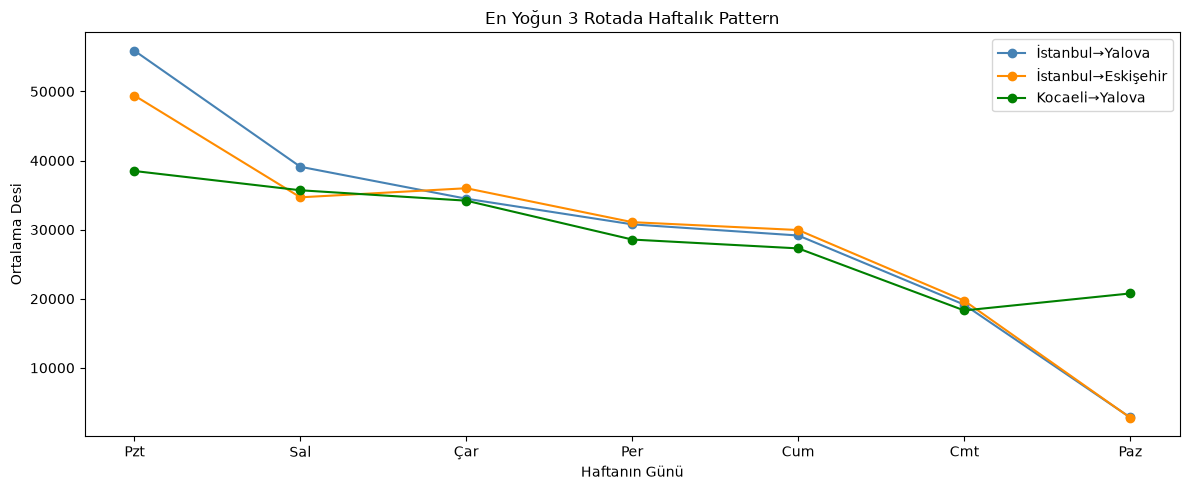

In [54]:
# --- PLOT 3: En yoğun 3 rotada haftalık pattern ---

gun_sira = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
gun_tr = ['Pzt','Sal','Çar','Per','Cum','Cmt','Paz']

top3 = (
    desi.groupby(['Çıkış Transfer Merkezi','Varış Transfer Merkezi'])['Toplam Desi']
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['steelblue', 'darkorange', 'green']

for (cikis, varis), color in zip(top3, colors):
    rota_df = desi[
        (desi['Çıkış Transfer Merkezi'] == cikis) &
        (desi['Varış Transfer Merkezi'] == varis)
    ]
    
    haftalik_rota = rota_df.groupby('gun_adi')['Toplam Desi'].mean().reindex(gun_sira)
    
    ax.plot(
        gun_tr,
        haftalik_rota.values,
        marker='o',
        label=f"{cikis}→{varis}",
        color=color
    )

ax.set_title("En Yoğun 3 Rotada Haftalık Pattern")
ax.set_ylabel("Ortalama Desi")
ax.set_xlabel("Haftanın Günü")
ax.legend()

plt.tight_layout()
plt.show()

2)KOORDİNATLAR 

In [55]:
koordinat = pd.read_excel('C:\\Users\\semanur\\Desktop\\HB_Yarisma\\data\\Koordinatlar v2.xlsx')

In [56]:
koordinat.head()

,Transfer Merkezi,Enlem,Boylam
0,Mersin,36.8000,34.6333
1,Kütahya,39.4167,29.9833
2,Kocaeli,40.8533,29.8815
3,Eskişehir,39.7767,30.5206
4,İstanbul,41.0082,28.9784


In [61]:
# Temel bilgiler
print("Shape:", koordinat.shape)
print("\nSütunlar:", list(koordinat.columns))
print("\nİlk 5 satır:")
print(koordinat.head())

print("\nEksik değer var mı?")
print(koordinat.isnull().sum())

print("\nTüm transfer merkezleri:")
print(koordinat.iloc[:, 0].tolist())  # İlk sütun TM adları

Shape: (18, 3)

Sütunlar: ['Transfer Merkezi', 'Enlem', 'Boylam']

İlk 5 satır:
  Transfer Merkezi    Enlem   Boylam
0           Mersin  36.8000  34.6333
1          Kütahya  39.4167  29.9833
2          Kocaeli  40.8533  29.8815
3        Eskişehir  39.7767  30.5206
4         İstanbul  41.0082  28.9784

Eksik değer var mı?
Transfer Merkezi    0
Enlem               0
Boylam              0
dtype: int64

Tüm transfer merkezleri:
['Mersin', 'Kütahya', 'Kocaeli', 'Eskişehir', 'İstanbul', 'Bilecik', 'Balıkesir', 'Şanlıurfa', 'Tekirdağ', 'Sivas', 'Yalova', 'Manisa', 'Isparta', 'Mardin', 'Erzincan', 'Zonguldak', 'Karaman', 'Denizli']


In [62]:
koordinat.dtypes

Transfer Merkezi     object
Enlem               float64
Boylam              float64
dtype: object

In [63]:
import numpy as np

In [65]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Dünya'nın yarıçapı (km)
    
    # Dereceyi radyana çevir
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Farklar
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Haversine formülü
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c  # km

# 18x18 mesafe matrisi oluştur
tm_listesi = koordinat['Transfer Merkezi'].tolist()
n = len(tm_listesi)

mesafe_matrisi = pd.DataFrame(index=tm_listesi, columns=tm_listesi, dtype=float)

for i, tm1 in enumerate(tm_listesi):
    for j, tm2 in enumerate(tm_listesi):
        lat1 = koordinat.loc[i, 'Enlem']
        lon1 = koordinat.loc[i, 'Boylam']
        lat2 = koordinat.loc[j, 'Enlem']
        lon2 = koordinat.loc[j, 'Boylam']
        mesafe_matrisi.loc[tm1, tm2] = haversine(lat1, lon1, lat2, lon2)

print("Mesafe matrisi (km) - İlk 5x5:")
print(mesafe_matrisi.iloc[:5, :5].round(0))

print("\nÖrnek mesafeler:")
print(f"İstanbul → Kocaeli : {mesafe_matrisi.loc['İstanbul','Kocaeli']:.0f} km")
print(f"İstanbul → Mersin  : {mesafe_matrisi.loc['İstanbul','Mersin']:.0f} km")
print(f"İstanbul → Mardin  : {mesafe_matrisi.loc['İstanbul','Mardin']:.0f} km")

Mesafe matrisi (km) - İlk 5x5:
           Mersin  Kütahya  Kocaeli  Eskişehir  İstanbul
Mersin        0.0    500.0    610.0      488.0     677.0
Kütahya     500.0      0.0    160.0       61.0     196.0
Kocaeli     610.0    160.0      0.0      131.0      78.0
Eskişehir   488.0     61.0    131.0        0.0     189.0
İstanbul    677.0    196.0     78.0      189.0       0.0

Örnek mesafeler:
İstanbul → Kocaeli : 78 km
İstanbul → Mersin  : 677 km
İstanbul → Mardin  : 1091 km


In [66]:
mesafe_matrisi.to_csv('C:\\Users\\semanur\\Desktop\\HB_Yarisma\\data2\\mesafe_matrisi.csv')
print("\nMesafe matrisi kaydedildi!")


Mesafe matrisi kaydedildi!


In [74]:
kiralık_arac = pd.read_excel(r"C:\Users\semanur\Desktop\HB_Yarisma\data\Kiralık_Araçlar.xlsx")

In [75]:
kiralık_arac.head()

,Çıkış Transfer Merkezi,Varış Transfer Merkezi,Araç sayısı,Araç Türü
0,İstanbul,Yalova,2,Tır
1,İstanbul,Eskişehir,2,Tır
2,Kocaeli,Yalova,1,Tır
3,İstanbul,Manisa,1,Tır
4,İstanbul,Balıkesir,1,Tır


In [76]:
print("Shape:", kiralık_arac.shape)
print("\nSütunlar:", list(kiralık_arac.columns))
print("\nTüm veri:")
print(kiralık_arac.to_string())
print("\nEksik değer:")
print(kiralık_arac.isnull().sum())

Shape: (12, 4)

Sütunlar: ['Çıkış Transfer Merkezi', 'Varış Transfer Merkezi', 'Araç sayısı', 'Araç Türü']

Tüm veri:
   Çıkış Transfer Merkezi Varış Transfer Merkezi  Araç sayısı Araç Türü
0                İstanbul                 Yalova            2       Tır
1                İstanbul              Eskişehir            2       Tır
2                 Kocaeli                 Yalova            1       Tır
3                İstanbul                 Manisa            1       Tır
4                İstanbul              Balıkesir            1       Tır
5                İstanbul               Tekirdağ            1       Tır
6                 Kocaeli               İstanbul            1       Tır
7                 Kocaeli               Tekirdağ            1       Tır
8                  Yalova              Eskişehir            1    Kamyon
9                 Kocaeli              Balıkesir            1    Kamyon
10                Kocaeli              Eskişehir            1    Kamyon
11                

Sadece spot araç kullanacağım rotalar olacak mı

In [77]:
# Kiralık rota listesi
kiralik_rotalar = set(
    zip(kiralık_arac['Çıkış Transfer Merkezi'], 
        kiralık_arac['Varış Transfer Merkezi'])
)

# Desi'deki tüm rotalar
desi_rotalar = set(
    zip(desi['Çıkış Transfer Merkezi'], 
        desi['Varış Transfer Merkezi'])
)

sadece_spot = desi_rotalar - kiralik_rotalar
sadece_kiralik = kiralik_rotalar - desi_rotalar

print(f"Toplam desi rotası      : {len(desi_rotalar)}")
print(f"Kiralık araç rotası     : {len(kiralik_rotalar)}")
print(f"Sadece spot gereken     : {len(sadece_spot)}")
print(f"Kiralik ama desi yok    : {len(sadece_kiralik)}")

print(f"\nÖrnek spot-only rotalar (ilk 5):")
for r in list(sadece_spot)[:5]:
    print(f"  {r[0]} → {r[1]}")

Toplam desi rotası      : 89
Kiralık araç rotası     : 12
Sadece spot gereken     : 77
Kiralik ama desi yok    : 0

Örnek spot-only rotalar (ilk 5):
  Balıkesir → Eskişehir
  Eskişehir → Bilecik
  Kocaeli → Isparta
  Eskişehir → Şanlıurfa
  Kocaeli → Erzincan


In [79]:
araç_kapasite_maliyet= pd.read_excel(r"C:\Users\semanur\Desktop\HB_Yarisma\data\Araç_Kapasite_Maliyet.xlsx")

In [80]:
araç_kapasite_maliyet.head()

,Araç Adı,Kapasite (desi),Kiralık Araç Günlük Kira (TL),Kiralık Araç Kilometre Başına Maliyet (TL),Spot Araç Sabit Günlük Maliyet (TL),Spot Kilometre Başına Maliyet (TL)
0,Tır,22400,7000,13,11700,25
1,Kamyon,12000,5000,10,7638,21
2,Hafif Kamyon,7200,5000,10,8750,20
3,Kamyonet,5600,3750,6,4750,18


In [82]:
print("Shape:", araç_kapasite_maliyet.shape)
print("\nSütunlar:", list(araç_kapasite_maliyet.columns))
print("\nTüm veri:")
print(araç_kapasite_maliyet.to_string())

Shape: (4, 6)

Sütunlar: ['Araç Adı', 'Kapasite (desi)', 'Kiralık Araç Günlük Kira (TL)', 'Kiralık Araç Kilometre Başına Maliyet (TL)', 'Spot Araç Sabit Günlük Maliyet (TL)', 'Spot Kilometre Başına Maliyet (TL)']

Tüm veri:
       Araç Adı  Kapasite (desi)  Kiralık Araç Günlük Kira (TL)  Kiralık Araç Kilometre Başına Maliyet (TL)  Spot Araç Sabit Günlük Maliyet (TL)  Spot Kilometre Başına Maliyet (TL)
0           Tır            22400                           7000                                          13                                11700                                  25
1        Kamyon            12000                           5000                                          10                                 7638                                  21
2  Hafif Kamyon             7200                           5000                                          10                                 8750                                  20
3      Kamyonet             5600                    